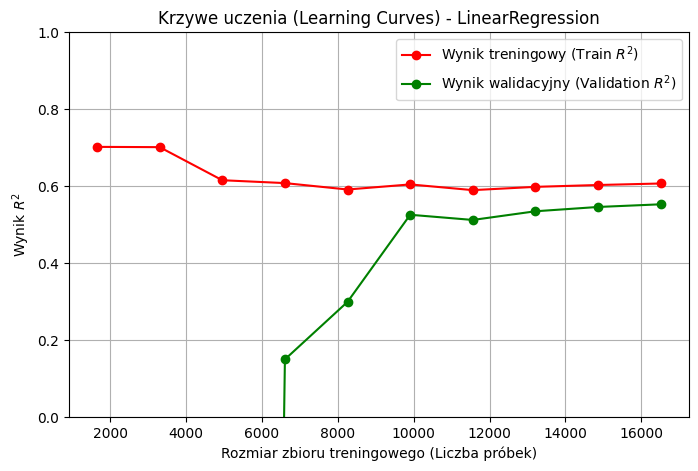

In [ ]:
# Dataset: California Housing
# Wymagania:
# Wygeneruj learning curves dla LinearRegression
# Zdiagnozuj: czy model ma underfitting, overfitting, czy jest dobrze dopasowany?
# Zaproponuj rozwiązanie jeśli jest problem
# Oczekiwany resultat:
# Wykres learning curves
# Diagnoza i rekomendacje

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve

# Wczytywaie danych
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target
# Obliczanie learning curves

train_sizes, train_scores, val_scores = learning_curve(
    LinearRegression(), X, y, train_sizes=np.linspace(0.1, 1.0, 10), cv=5,
    scoring='r2', n_jobs=-1)

# Obliczanie średnich wyników z walidacji krzyżowej (CV)
train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

# Tworzenie wykresu
plt.figure(figsize=(8, 5))
plt.plot(
    train_sizes,
    train_scores_mean,
    "o-",
    color="r",
    label="Wynik treningowy (Train $R^2$)",
)
plt.plot(
    train_sizes,
    val_scores_mean,
    "o-",
    color="g",
    label="Wynik walidacyjny (Validation $R^2$)",
)

plt.title("Krzywe uczenia (Learning Curves) - LinearRegression")
plt.xlabel("Rozmiar zbioru treningowego (Liczba próbek)")
plt.ylabel("Wynik $R^2$")
plt.grid(True)
plt.legend(loc="best")
plt.ylim(0, 1)  # Skala R2 od 0 do 1 dla czytelności

plt.show()

#Model wykazuje silny UNDERFITTING (Niedouczenie).

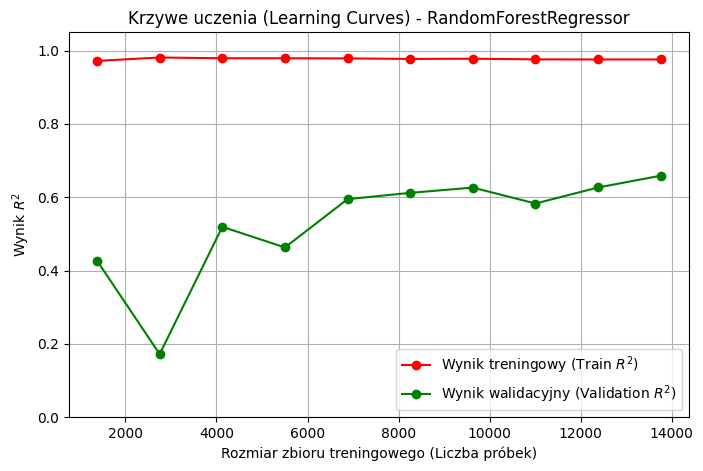

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor  # ZMIANA: Nowy model
from sklearn.model_selection import learning_curve

# Twoje wczytywanie danych
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target


# Obliczanie learning curves dla nowego modelu
train_sizes, train_scores, val_scores = learning_curve(
    RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42),  # ZMIANA MODELU
    X,
    y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=3,
    scoring="r2",
    n_jobs=-1,
)


# Obliczanie średnich wyników (niezbędne do poprawnego wyświetlenia linii)
train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

# Tworzenie wykresu
plt.figure(figsize=(8, 5))
plt.plot(
    train_sizes,
    train_scores_mean,
    "o-",
    color="r",
    label="Wynik treningowy (Train $R^2$)",
)
plt.plot(
    train_sizes,
    val_scores_mean,
    "o-",
    color="g",
    label="Wynik walidacyjny (Validation $R^2$)",
)

plt.title("Krzywe uczenia (Learning Curves) - RandomForestRegressor")
plt.xlabel("Rozmiar zbioru treningowego (Liczba próbek)")
plt.ylabel("Wynik $R^2$")
plt.grid(True)
plt.legend(loc="best")
plt.ylim(0, 1.05)

plt.show()

In [ ]:
# Zadanie otwarte czyli minimalna wersja (w datasetach Titanic, Digits, California Housing) 
# wytrenować model regresji liniowej lub logistycznej z za pomocą gradient descent i poeksperymentować z learning rate,
# aby algorytmy były zbieżne.
# Zadanie wymaga zrobienie regresji liniowej oraz logistycznej w zależności od datasetu. 
# Teoretycznie dopiero na następnej lekcji będziemy pogłębiać temat logistycznej,
# ale dobrze jak sobie nad tym już posiedzicie.

import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_digits
from sklearn.model_selection import (train_test_split,learning_curve)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

# Wczytanie danych
digits = load_digits()
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

# Skalowanie
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = SGDClassifier(
    loss="log_loss",   
    learning_rate="constant",
    eta0=0.01,         
    max_iter=2000,
    tol=1e-3,
    random_state=42
)
